
<p align="center"><b><font color="cyan" size="6">HealthConnect Project-Week4</font></b></p>



<p><font color="gold">My objective this week, as a Data Analytics intern, is not to solve the entire HealthConnect project, but to answer the central question from a data perspective: what factors are associated with appointment no-shows, and how can appointment data inform a reduction in these no-shows. It is also to provide the data understanding and insights needed to support the other tracks.</font></p>

<p align="center"><b><font color="cyan" size="6"> Importing the necessary libraries for the project </font></b></p>

In [1]:
import pandas as pd
import numpy as np


<p align="center"><b><font color="cyan" size="6"> Data Loading </font></b></p>

In [2]:
#chargement du dataset
df = pd.read_csv('/content/HealthConnect_Appointment_Data.csv')

In [3]:
# Dimensions et aperçu
print("Dimensions :", df.shape)


Dimensions : (5000, 18)


In [4]:
# Structure des colonnes et types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

<p align="center"><b><font color="cyan" size="6"> Data Status Check </font></b></p>

In [5]:
df['gender'].unique()


array(['Female', 'Male', 'Prefer not to say'], dtype=object)

In [6]:
df['gender'].value_counts()

,count
gender,
Female,2488
Male,2404
Prefer not to say,108


In [7]:
df['age_group'].unique()

array(['35-44', '25-34', '45-54', '55-64', '65+', '18-24'], dtype=object)

In [8]:
df['age_group'].value_counts()

,count
age_group,
65+,1241
35-44,819
55-64,800
45-54,793
25-34,783
18-24,564


In [9]:
df['appointment_type'].unique()

array(['Follow-up', 'Specialist Consultation', 'General Consultation',
       'Diagnostic Test'], dtype=object)

In [10]:
df['appointment_type'].value_counts()

,count
appointment_type,
General Consultation,2086
Follow-up,1421
Specialist Consultation,900
Diagnostic Test,593


In [11]:
print("Âge min :", df['age'].min())
print("Âge max :", df['age'].max())

Âge min : 18
Âge max : 80


In [12]:
df['appointment_day'].value_counts()

,count
appointment_day,
Wednesday,737
Sunday,737
Friday,728
Saturday,724
Monday,701
Tuesday,689
Thursday,684


In [13]:
df['reminder_sent'].unique()

array(['Yes', 'No'], dtype=object)

In [14]:
df['reminder_sent'].value_counts()

,count
reminder_sent,
Yes,3634
No,1366


In [15]:
df['reminder_channel'].unique()

array(['WhatsApp', 'SMS', 'Email', nan], dtype=object)

In [16]:
df['reminder_channel'].value_counts()

,count
reminder_channel,
SMS,2000
WhatsApp,1101
Email,533


In [17]:
#  identifions les lignes où reminder_channel est manquant
missing_channel = df[df['reminder_channel'].isnull()]

# Vérifions la valeur de reminder_sent pour ces lignes précises
missing_channel['reminder_sent'].value_counts()

,count
reminder_sent,
No,1366


In [18]:
# Étape 2 : vérifins que toutes les lignes où reminder_sent = "No" ont bien reminder_channel manquant et qu'aucune ligne où reminder_sent = "Yes" n'a de reminder_channel manquant
pd.crosstab(df['reminder_sent'], df['reminder_channel'].isnull())

reminder_channel,False,True
reminder_sent,,
No,0,1366
Yes,3634,0


In [19]:
df['waiting_time_minutes'].describe()

,waiting_time_minutes
count,4940.000000
mean,24.189676
std,10.863184
min,2.000000
25%,17.000000
50%,24.000000
75%,32.000000
max,68.000000


In [20]:
df['appointment_outcome'].unique()

array(['No-Show', 'Attended', 'Cancelled'], dtype=object)

In [21]:
df['appointment_outcome'].value_counts()

,count
appointment_outcome,
No-Show,2423
Attended,2314
Cancelled,263


In [22]:
# Table croisée : appointment_outcome vs valeur manquante de waiting_time_minutes
pd.crosstab(df['appointment_outcome'], df['waiting_time_minutes'].isnull())

waiting_time_minutes,False,True
appointment_outcome,,
Attended,2293,21
Cancelled,261,2
No-Show,2386,37


In [23]:
pd.crosstab(df['appointment_outcome'], df['distance_to_clinic_km'].isnull())

distance_to_clinic_km,False,True
appointment_outcome,,
Attended,2275,39
Cancelled,259,4
No-Show,2376,47


In [24]:
#Aperçu des données
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


<p><font color="gold">The reminder_channel column contains 1,366 missing values 27.3% of records. Cross-tabulation with reminder_sent confirms it so this is not a data quality issue requiring imputation but it reflects a logical dependency between the two fields (no channel is recorded when no reminder was sent). Additionally, the date columns (booking_date, appointment_date) are currently stored as object (text) type and should be converted to datetime format </font></p>

<p align="center"><b><font color="cyan" size="6"> Data Quality</font></b></p>

In [25]:
# Doublons
print("\nVALEURS DOUBLONS :")
df[df.duplicated()]


VALEURS DOUBLONS :


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome


In [26]:
# valeurs aberrantes
# Âge
print("Âge min :", df['age'].min())
print("Âge max :", df['age'].max())
print("Âges négatifs :", (df['age'] < 0).sum())
print("Âges > 110 ans :", (df['age'] > 110).sum())

Âge min : 18
Âge max : 80
Âges négatifs : 0
Âges > 110 ans : 0


In [27]:
# booking_lead_days
print("Lead time min :", df['booking_lead_days'].min())
print("Lead time max :", df['booking_lead_days'].max())
print("Lead time négatif :", (df['booking_lead_days'] < 0).sum())

Lead time min : 0
Lead time max : 60
Lead time négatif : 0


In [28]:
# previous_appointments et previous_no_shows
incoherent = df[df['previous_no_shows'] > df['previous_appointments']]
print("Lignes incohérentes  :", len(incoherent))
incoherent.head()

Lignes incohérentes  : 0


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome


In [29]:
# waiting_time_minutes
print("Waiting time min :", df['waiting_time_minutes'].min())
print("Waiting time max :", df['waiting_time_minutes'].max())
print("Waiting time négatif :", (df['waiting_time_minutes'] < 0).sum())

Waiting time min : 2.0
Waiting time max : 68.0
Waiting time négatif : 0


In [30]:
# distance_to_clinic_km
print("Distance min :", df['distance_to_clinic_km'].min())
print("Distance max :", df['distance_to_clinic_km'].max())
print("Distance négative :", (df['distance_to_clinic_km'] < 0).sum())

Distance min : 0.5
Distance max : 45.0
Distance négative : 0


<p><font color="gold">The dataset shows strong structural integrity. No duplicate records were found, whether checked as full-row duplicates or duplicates on appointment_id. No outliers or invalid values were detected across the  columns. The only data quality considerations identified relate to missing values in reminder_channel, waiting_time_minutes, and distance_to_clinic_km, which have been assessed separately above.</font></p>


<p align="center"><b><font color="cyan" size="6">Data Cleaning</font></b></p>


In [31]:
# Conversion des colonnes de dates en format dates
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y', errors='coerce')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y', errors='coerce')

# Vérification du type après conversion
df[['booking_date', 'appointment_date']].dtypes

,0
booking_date,datetime64[ns]
appointment_date,datetime64[ns]


In [32]:
# Comparer moyenne et médiane pour choisir la meilleure option
print("waiting_time_minutes - moyenne:", df['waiting_time_minutes'].mean(), "| médiane:", df['waiting_time_minutes'].median())
print("distance_to_clinic_km - moyenne:", df['distance_to_clinic_km'].mean(), "| médiane:", df['distance_to_clinic_km'].median())

waiting_time_minutes - moyenne: 24.189676113360324 | médiane: 24.0
distance_to_clinic_km - moyenne: 10.109572301425661 | médiane: 8.7


In [33]:
#changement des valeurs nulles de reminder-channel par No-reminder
df['reminder_channel'] = df['reminder_channel'].fillna('No-reminder')
df['reminder_channel'].value_counts()

,count
reminder_channel,
SMS,2000
No-reminder,1366
WhatsApp,1101
Email,533


In [34]:
# waiting_time_minutes : moyenne et médiane proches donc la moyenne convient le mieux à remplacer les valeurs nulles
df['waiting_time_minutes'] = df['waiting_time_minutes'].fillna(df['waiting_time_minutes'].mean())

# distance_to_clinic_km : distribution asymétrique donc la médiane est plus mieux à utiliser
df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(df['distance_to_clinic_km'].median())



<p><font color="gold">Missing values were imputed using different strategies based on each column's distribution. For waiting_time_minutes, the mean and median are nearly identical (24.19 vs 24.0), indicating a symmetric distribution, so missing values were filled with the mean. For distance_to_clinic_km, the mean (10.11) is noticeably higher than the median (8.7) indicating a right-skewed distribution likely driven by a small number of patients living far from the clinic so we used the median  to avoid distorting the imputed values with these extreme cases. For reminder_channel, missing values were replaced with the explicit category 'No-reminder'because with the earlier finding that these gaps correspond exactly to appointments where no reminder was sent</font></p>


<p align="center"><b><font color="cyan" size="6">Problem understanding</font></b></p>

In [35]:
# Simple vérification du nombre de catégories/valeurs par variable candidate

for col in ['gender', 'age_group', 'appointment_type', 'reminder_sent', 'appointment_day']:
    print(f"{col} : {df[col].nunique()} catégories → {list(df[col].unique())}")

gender : 3 catégories → ['Female', 'Male', 'Prefer not to say']
age_group : 6 catégories → ['35-44', '25-34', '45-54', '55-64', '65+', '18-24']
appointment_type : 4 catégories → ['Follow-up', 'Specialist Consultation', 'General Consultation', 'Diagnostic Test']
reminder_sent : 2 catégories → ['Yes', 'No']
appointment_day : 7 catégories → ['Tuesday', 'Friday', 'Wednesday', 'Thursday', 'Monday', 'Sunday', 'Saturday']


In [36]:
# Aperçu rapide des plages de valeurs pour les variables numériques candidates
print("booking_lead_days :",     df['booking_lead_days'].min(), "à", df['booking_lead_days'].max())
print("previous_no_shows :",     df['previous_no_shows'].min(), "à", df['previous_no_shows'].max())
print("distance_to_clinic_km :", df['distance_to_clinic_km'].min(), "à", df['distance_to_clinic_km'].max())

booking_lead_days : 0 à 60
previous_no_shows : 0 à 5
distance_to_clinic_km : 0.5 à 45.0


<p><font color="gold">booking_lead_days is identified as a potentially relevant variable,  the literature on appointment no-shows commonly associates longer   booking lead times with higher no-show rates
   previous_no_shows is identified as a potentially relevant variable, as a patient's prior attendance history is commonly considered one of the strongest predictors of future no-show behavior
  reminder_sent and reminder_channel are also identified as potentially relevant variables: as reminder interventions are commonly associated with reduced no-show rates in healthcare settings.
   Same thing for the distance between the hospital and the patient home and appointment_day and appointment_type. But
    these relationships will be explored quantitatively in a later phase on week 5 </font></p>

BUSINESS QUESTIONS

Does the time between booking and the appointment

1. Does the time between booking and the appointment (booking_lead_days) can affect the likekihood of no-show?  
2. Does reminder_sent and reminder_channel reduce the likelihood of a no-show?  

3. Do patients with a history of missed appointments previous_no_shows show a higher risk of no-show recurrence?

4. Do certain appointment days  or appointment types  show higher no-show rates than others?

 5. Does the distance between the patient's location and the clinic can  influence attendance?



My proposed Approach

 1 . Quantify the no-show rate for each identified variable to calculate the five proposed KPIs

 2 . Visualise these results to make them easily interpretable

 3 . Prioritise the most influential factors and translate them into concrete, actionable recommendations for the clinic

Conclusion

This phase has turned a raw appointment dataset into a clear, validated foundation for analysis. With data quality confirmed, relevant factors identified, and KPIs scoped, this project is well positioned to move from understanding to insight in Week 5

<p align="center"><b><font color="cyan" size="5">Week5 — HealthConnect Solution development Implementation</font></b></p>

<p><font color="gold">Building on the data preparation and variable identification completed in Week 4, Our Week 5 shifts the focus from planning to practical analysis. This phase investigates the actual relationships between appointment outcomes and the key factors identified previously  including appointment characteristics, patient characteristics, previous appointment history, reminders, waiting time, and distance to clinic. From this exploratory analysis  patterns will be translated into meaningful business insights to directly support HealthConnect's goal of reducing missed appointments.</font></p>

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def noshow_rate_by(column):
    """Returns the % distribution of appointment_outcome for each category of a column"""
    # Explicitly set observed=False to silence the FutureWarning for groupby on categorical data
    result = df.groupby(column, observed=False)['appointment_outcome'].value_counts(normalize=True).unstack().fillna(0) * 100
    return result.round(2)

<p align="center"><b><font color="cyan" size="6">Appointment Characteristics</font></b></p>

In [38]:
noshow_rate_by('appointment_type')

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,45.87,4.38,49.75
Follow-up,43.35,5.42,51.23
General Consultation,48.27,5.08,46.64
Specialist Consultation,46.56,6.00,47.44


In [39]:
noshow_rate_by('appointment_day')

appointment_outcome,Attended,Cancelled,No-Show
appointment_day,,,
Friday,49.04,4.40,46.57
Monday,43.79,6.56,49.64
Saturday,47.51,5.66,46.82
Sunday,45.05,4.48,50.47
Thursday,45.18,5.85,48.98
Tuesday,49.06,3.92,47.02
Wednesday,44.37,5.97,49.66


In [40]:
noshow_rate_by('appointment_time')

appointment_outcome,Attended,Cancelled,No-Show
appointment_time,,,
Afternoon,46.13,5.49,48.38
Evening,44.77,5.45,49.78
Morning,46.88,4.98,48.14


<p align="center"><b><font color="cyan" size="6"> Patients Characteristics</font></b></p>

In [41]:
noshow_rate_by('gender')

appointment_outcome,Attended,Cancelled,No-Show
gender,,,
Female,46.34,5.23,48.43
Male,45.88,5.41,48.71
Prefer not to say,53.70,2.78,43.52


In [42]:
noshow_rate_by('age_group')

appointment_outcome,Attended,Cancelled,No-Show
age_group,,,
18-24,45.57,4.26,50.18
25-34,45.08,4.21,50.70
35-44,45.67,5.98,48.35
45-54,46.03,5.93,48.05
55-64,45.00,4.25,50.75
65+,48.75,6.12,45.12


In [43]:
df.groupby('appointment_outcome')['age'].mean()

,age
appointment_outcome,
Attended,49.247623
Cancelled,50.152091
No-Show,48.215023


<p align="center"><b><font color="cyan" size="6"> Previous Appointment Characteristics</font></b></p>

In [44]:
noshow_rate_by('previous_no_shows')

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,50.46,6.03,43.51
1,42.25,4.26,53.49
2,36.30,4.34,59.36
3,29.49,2.56,67.95
4,33.33,0.00,66.67
5,0.00,0.00,100.00


In [45]:
df['previous_no_shows'].value_counts().sort_index()

,count
previous_no_shows,
0,2921
1,1548
2,438
3,78
4,12
5,3


<p align="center"><b><font color="cyan" size="6"> Reminders</font></b></p>

In [46]:
noshow_rate_by('reminder_sent')

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,42.68,5.93,51.39
Yes,47.63,5.01,47.36


In [47]:
noshow_rate_by('reminder_channel')

appointment_outcome,Attended,Cancelled,No-Show
reminder_channel,,,
Email,46.53,5.07,48.41
No-reminder,42.68,5.93,51.39
SMS,49.60,4.65,45.75
WhatsApp,44.60,5.63,49.77


<p align="center"><b><font color="cyan" size="6"> Waiting time </font></b></p>

In [48]:
df.groupby('appointment_outcome')['waiting_time_minutes'].mean()

,waiting_time_minutes
appointment_outcome,
Attended,24.288238
Cancelled,23.221975
No-Show,24.200585


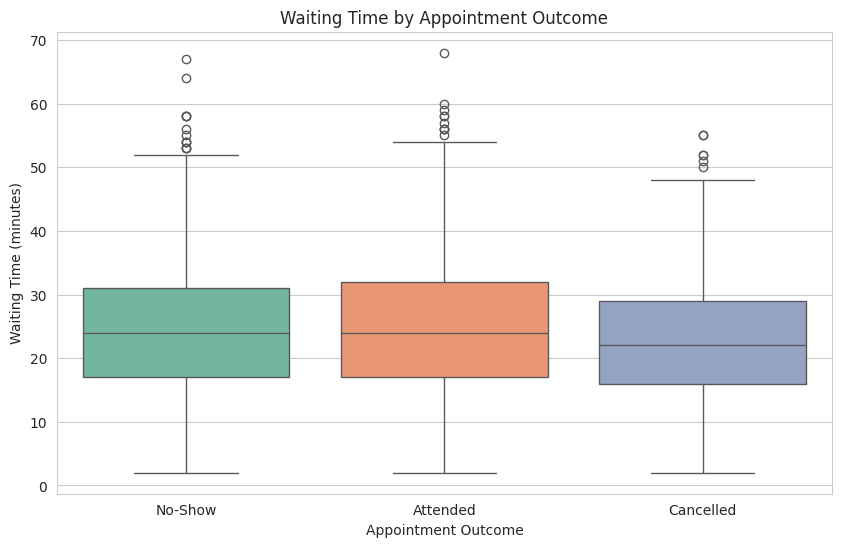

In [49]:
sns.boxplot(data=df, x='appointment_outcome', y='waiting_time_minutes',
            hue='appointment_outcome', palette='Set2', legend=False)
plt.title('Waiting Time by Appointment Outcome')
plt.xlabel('Appointment Outcome')
plt.ylabel('Waiting Time (minutes)')
plt.show()

<p align="center"><b><font color="cyan" size="6"> Distance to clinic </font></b></p>

In [50]:
df.groupby('appointment_outcome')['distance_to_clinic_km'].mean()

,distance_to_clinic_km
appointment_outcome,
Attended,9.652377
Cancelled,10.090114
No-Show,10.495955


In [51]:
df['distance_group'] = pd.cut(df['distance_to_clinic_km'], bins=[0, 5, 15, 30, 1000],
                                 labels=['0-5 km', '5-15 km', '15-30 km', '30+ km'])
noshow_rate_by('distance_group')

appointment_outcome,Attended,Cancelled,No-Show
distance_group,,,
0-5 km,48.96,4.58,46.45
5-15 km,46.91,5.63,47.46
15-30 km,41.96,5.13,52.91
30+ km,29.17,2.78,68.06


<p align="center"><b><font color="cyan" size="6"> Cancellation </font></b></p>

In [52]:

df['lead_time_group'] = pd.cut(df['booking_lead_days'], bins=[-1, 0, 7, 30, 90, 1000],
                                  labels=['Same day', '1-7 days', '8-30 days', '31-90 days', '90+ days'])
noshow_rate_by('lead_time_group')

appointment_outcome,Attended,Cancelled,No-Show
lead_time_group,,,
Same day,70.59,4.71,24.71
1-7 days,65.95,5.77,28.29
8-30 days,54.83,4.96,40.21
31-90 days,34.10,5.40,60.49
90+ days,0.00,0.00,0.00


<p align="center"><b><font color="cyan" size="6"> No show outcome</font></b></p>

In [53]:
df['appointment_outcome'].value_counts()

,count
appointment_outcome,
No-Show,2423
Attended,2314
Cancelled,263


In [54]:
df['appointment_outcome'].value_counts(normalize=True) * 100

,proportion
appointment_outcome,
No-Show,48.46
Attended,46.28
Cancelled,5.26


<p align="center"><b><font color="cyan" size="6"> Visualization </font></b></p>

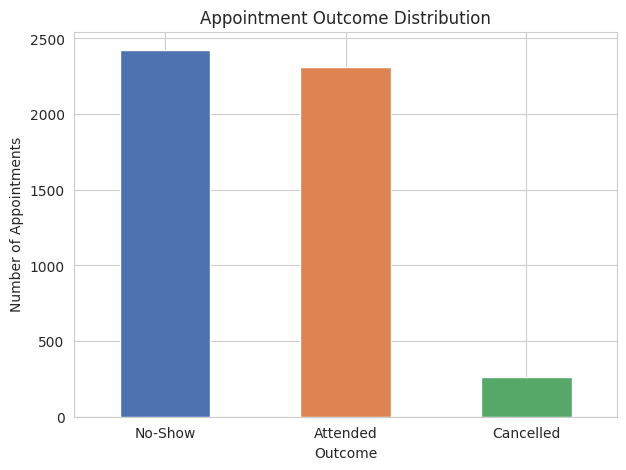

In [55]:
#  Overall
plt.figure(figsize=(7,5))
df['appointment_outcome'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Appointment Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=0)
plt.show()

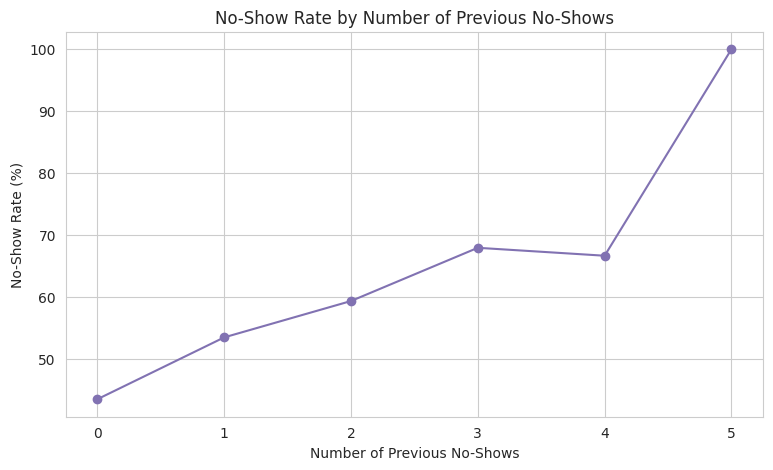

In [56]:
#  No-Show History
plt.figure(figsize=(9,5))
noshow_rate_by('previous_no_shows')['No-Show'].plot(kind='line', marker='o', color='#8172B2')
plt.title('No-Show Rate by Number of Previous No-Shows')
plt.xlabel('Number of Previous No-Shows')
plt.ylabel('No-Show Rate (%)')
plt.show()

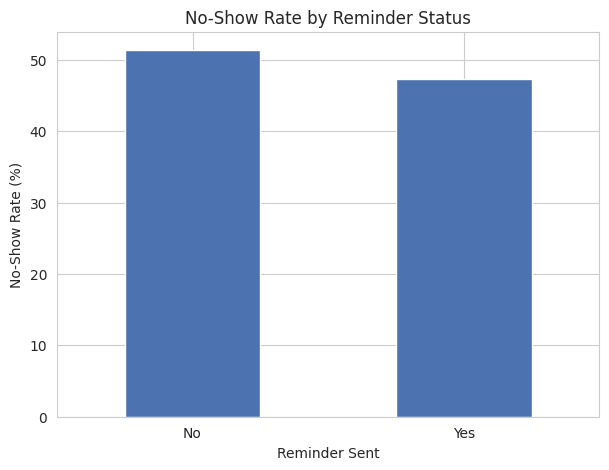

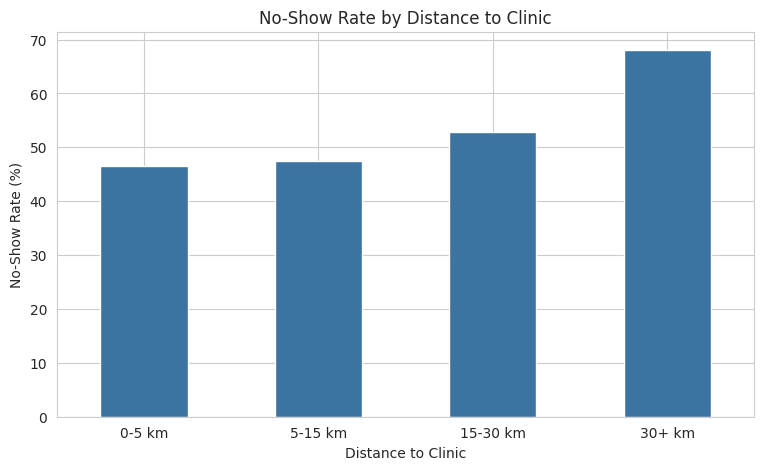

In [57]:
#  No-schow rate by Reminder Status
plt.figure(figsize=(7,5))
noshow_rate_by('reminder_sent')['No-Show'].plot(kind='bar', color='#4C72B0')
plt.title('No-Show Rate by Reminder Status')
plt.xlabel('Reminder Sent')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.show()

#No-show rate by Distance
plt.figure(figsize=(9,5))
noshow_rate_by('distance_group')['No-Show'].plot(kind='bar', color='#3D73A1')
plt.title('No-Show Rate by Distance to Clinic')
plt.xlabel('Distance to Clinic')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.show()

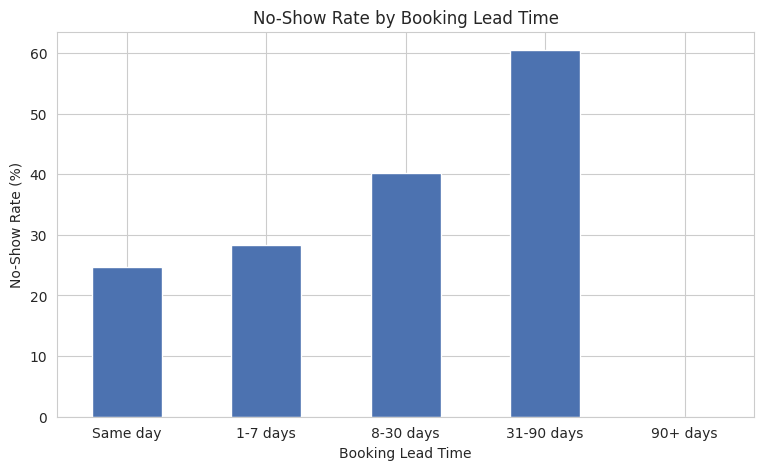

In [58]:
#  No-schow rate by Lead Time
plt.figure(figsize=(9,5))
noshow_rate_by('lead_time_group')['No-Show'].plot(kind='bar', color='#4C72B0')
plt.title('No-Show Rate by Booking Lead Time')
plt.xlabel('Booking Lead Time')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.show()



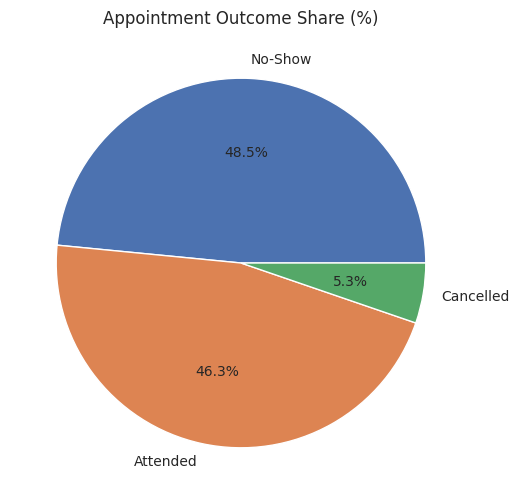

In [59]:
plt.figure(figsize=(6,6))
df['appointment_outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                                  colors=['#4C72B0','#DD8452','#55A868'])
plt.title('Appointment Outcome Share (%)')
plt.ylabel('')
plt.show()




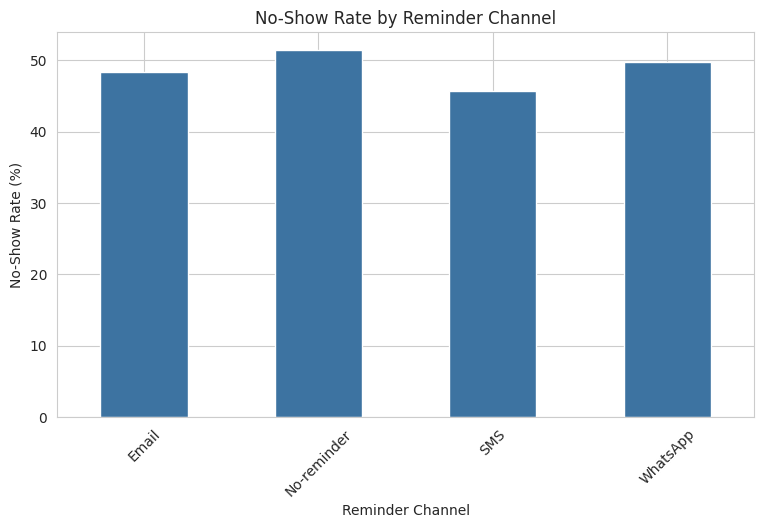

In [60]:
#No-schow rate by reminder channel
noshow_by_channel = df.groupby('reminder_channel')['appointment_outcome'].value_counts(normalize=True).unstack().fillna(0) * 100

plt.figure(figsize=(9,5))
noshow_by_channel['No-Show'].plot(kind='bar', color='#3D73A1')
plt.title('No-Show Rate by Reminder Channel')
plt.xlabel('Reminder Channel')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=45)
plt.show()

<p align="center"><b><font color="cyan" size="6">KPI Interpretations</font></b></p>

<b>KPI 1: Overall No-Show Rate 48.46%, Nearly one in two scheduled appointments results in a no-show, exceeding the Attended rate 46.28%. This confirms that missed appointments are not a marginal issue but the clinic's primary operational challenge, directly validating the urgency of the HealthConnect project's central question

<b>KPI 2:No-Show Rate by Booking Lead Time.</b> The no-show rate rises steadily from 24.71% for same-day appointments to 60.49% for appointments booked 31-90 days in advance . This confirms booking lead time as one of the strongest predictors of attendance: the longer patients wait between booking and their appointment, the more likely they are to forget or deprioritise it

<b>KPI 3: No-Show Rate by Reminder Status,</b> Patients who received a reminder show a slightly lower no-show rate 47.36% than those who did not 51.39% . Breaking this down by channel, SMS reminders show the lowest no-show rate 45.75%, while Email, WhatsApp, and no-reminder cases cluster closer to 48-51%. The effect is real but modest, suggesting reminders alone are not sufficient to solve the no-show problem, though SMS appears to be the most effective channel available

<b>KPI 4: No-Show Rate by Distance to Clinic, </b> No-show rate rises from 46.45% for patients within 5km to 68.06% for those living 30km or more from the clinic . This confirms distance as a genuine attendance barrier likely linked to transport cost, time, or access difficulties rather than patient willingness alone

<b>KPI 5: No-Show Rate by Prior No-Show History.</b> No-show rate increases almost linearly with prior no-show history, from 43.51% (no history) to 66-68% for patients with 3-4 previous no-shows, reaching 100% at 5 previous no-shows. This is the strongest signal in the dataset and confirms that past behaviour is highly predictive of future attendance

<p align="center"><b><font color="cyan" size="6"> Business Insights </font></b></p>

<b>Insight 1 : No-shows are the clinic's largest single outcome category. At 48.46%, no-shows outnumber both attended appointments and cancellations combined in relative terms. Implication: even modest improvements in this rate would free up a substantial number of appointment slots directly improving scheduling efficienc




<b>Insight 2 : Prior no-show history is the single strongest predictor of future no-shows


<b>Insight 3 : Booking far in advance significantly increases no-show risk. Implication: the clinic could benefit from shorter default booking windows where clinically appropriate, or from reinforced reminder sequences specifically for long-lead-time bookings

<b>Insight 4 : Reminders help but modestly and channel choice matters  combined with SMS outperforming other channels, suggests reminders are a useful but partial lever

<b>Insight 5 :  Distance is a structural, not just behavioural, barrier. The steady rise in no-show rate with distance 46.5% to 68.1% points to a practical access issue rather than pure forgetfulness

<p align="center"><b><font color="cyan" size="6"> Recommendations </font></b></p>

<b>Recommendation 1 :</b> Introduce a patient risk flag based on previous_no_shows, prioritising patients with 2 or more prior no-shows for reinforced reminder sequences or confirmation calls

<b>Recommendation 2 : </b> Shift reminder delivery toward SMS as the primary channel, given its comparatively lower associated no-show rate, while maintaining other channels as backup options


<b>Recommendation 3 : </b> For appointments booked more than 30 days in advance, implement an additional reminder closer to the booking date rather than relying on a single reminder


<b>Recommendation 5 : </b> Establish routine monitoring of the five KPIs developed this week, allowing HealthConnect to track whether future interventions (reminders, scheduling changes) measurably reduce the no-show rate over time

<p align="center"><b><font color="cyan" size="6"> Conclusion </font></b></p>

<p><font color="gold">Week 5 has moved the HealthConnect Data Analytics work from planning into concrete, evidence-based analysis. Five KPIs were calculated and interpreted, revealing prior no-show history, booking lead time, and distance to clinic as the strongest drivers of missed appointments, while reminders  particularly via SMS  offer a modest but real protective effect. These findings together with the five insights and recommendations above provide a solid quantified foundation for Week 6 </font></p>

<p align="center"><b><font color="cyan" size="6"> Week 6- Advanced Analysis </font></b></p>

**Validation ou vérification statiques des KPI calculés dans la semaine 5**
============================================================

In [61]:
from scipy.stats import chi2_contingency

def validate_relationship(column):
    """Runs a Chi-square test between a column and appointment_outcome"""
    contingency = pd.crosstab(df[column], df['appointment_outcome'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    significant = "YES (p < 0.05)" if p_value < 0.05 else "NO (p >= 0.05)"
    print(f"{column}: chi2={chi2:.2f}, p-value={p_value:.5f} → Statistically significant: {significant}")
    return chi2, p_value

In [62]:
results = {}
for col in ['previous_no_shows', 'lead_time_group', 'distance_group', 'reminder_sent', 'reminder_channel']:
    chi2, p = validate_relationship(col)
    results[col] = {'chi2': chi2, 'p_value': p}

previous_no_shows: chi2=83.38, p-value=0.00000 → Statistically significant: YES (p < 0.05)
lead_time_group: chi2=322.42, p-value=0.00000 → Statistically significant: YES (p < 0.05)
distance_group: chi2=23.47, p-value=0.00065 → Statistically significant: YES (p < 0.05)
reminder_sent: chi2=10.20, p-value=0.00610 → Statistically significant: YES (p < 0.05)
reminder_channel: chi2=18.02, p-value=0.00618 → Statistically significant: YES (p < 0.05)


<p><font color="gold">All five KPIs developed in Week 5 were statistically validated using Chi-square tests of independence against appointment_outcome. Each relationship proved significant at the 0.05 threshold, with booking_lead_days showing by far the strongest statistical association, followed by previous_no_shows, distance_group , reminder_channel , and reminder_sent .For week5  the validation instead refines the relative importance ranking, positioning booking lead time as the single most statistically robust predictor of appointment no-shows in this dataset</font></p>

Segmentation croisée
==============================================================================================================================

In [63]:
# Création d'un score de risque combiné basé sur les 2 facteurs les plus forts
df['high_risk_history'] = df['previous_no_shows'] >= 2
df['high_risk_leadtime'] = df['booking_lead_days'] > 30

df['risk_segment'] = 'Low Risk'
df.loc[df['high_risk_history'] & ~df['high_risk_leadtime'], 'risk_segment'] = 'History Risk Only'
df.loc[~df['high_risk_history'] & df['high_risk_leadtime'], 'risk_segment'] = 'Lead Time Risk Only'
df.loc[df['high_risk_history'] & df['high_risk_leadtime'], 'risk_segment'] = 'Combined High Risk'

noshow_rate_by('risk_segment')

appointment_outcome,Attended,Cancelled,No-Show
risk_segment,,,
Combined High Risk,23.61,3.43,72.96
History Risk Only,43.96,4.36,51.68
Lead Time Risk Only,35.22,5.61,59.17
Low Risk,59.55,5.23,35.22


In [64]:
# Validation statistique de ce nouveau segment combiné
validate_relationship('risk_segment')

risk_segment: chi2=337.03, p-value=0.00000 → Statistically significant: YES (p < 0.05)


(np.float64(337.0258605728788), np.float64(9.400588190362754e-70))

<p><font color="gold">Combining the two strongest validated predictors  previous_no_shows  and booking_lead_days into a single risk segment produces the most powerful predictor identified across the entire analysis . Patients falling into the Combined High Risk segment show a 72.96% no-show rate, compared to 35.22% for Low  patients . This effect is close to additive , confirming that patients carrying both risk factors should be treated as a distinct, high-priority segment rather than assessed on either factor alone.</font></p>

Visualization
===============================================================

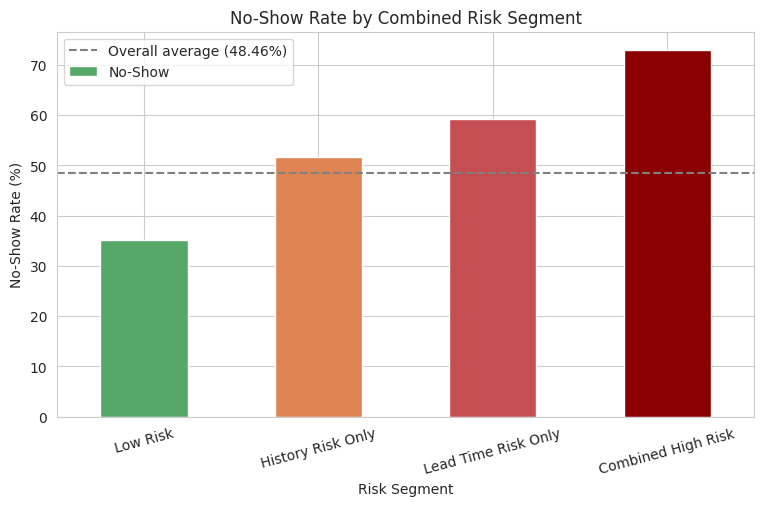

In [65]:
plt.figure(figsize=(9,5))
order = ['Low Risk', 'History Risk Only', 'Lead Time Risk Only', 'Combined High Risk']
noshow_rate_by('risk_segment').loc[order, 'No-Show'].plot(kind='bar', color=['#55A868','#DD8452','#C44E52','#8B0000'])
plt.title('No-Show Rate by Combined Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=15)
plt.axhline(y=48.46, color='grey', linestyle='--', label='Overall average (48.46%)')
plt.legend()
plt.show()

Analyse par segment patients
==============================================================================================================================

In [66]:
#  Vérifions si le risque combiné varie-t-il selon le genre
pd.crosstab(df['gender'], df['risk_segment'], normalize='index') * 100

risk_segment,Combined High Risk,History Risk Only,Lead Time Risk Only,Low Risk
gender,,,,
Female,3.858521,6.028939,43.408360,46.704180
Male,5.449251,6.031614,44.093178,44.425957
Prefer not to say,5.555556,2.777778,48.148148,43.518519


In [67]:
# Vérifions si le risque combiné varie-t-il selon la tranche d'âge
pd.crosstab(df['age_group'], df['risk_segment'], normalize='index') * 100

risk_segment,Combined High Risk,History Risk Only,Lead Time Risk Only,Low Risk
age_group,,,,
18-24,4.255319,6.737589,44.858156,44.148936
25-34,4.597701,6.641124,46.360153,42.401022
35-44,2.930403,5.738706,43.589744,47.741148
45-54,5.170240,5.548550,45.271122,44.010088
55-64,6.125000,5.625000,45.375000,42.875000
65+,4.754230,5.801773,40.048348,49.395649


In [68]:
#  Vérifions si le risque combiné varie-t-il selon le type de rendez-vous
pd.crosstab(df['appointment_type'], df['risk_segment'], normalize='index') * 100

risk_segment,Combined High Risk,History Risk Only,Lead Time Risk Only,Low Risk
appointment_type,,,,
Diagnostic Test,5.902192,6.239460,47.048904,40.809444
Follow-up,4.433498,6.474314,44.616467,44.475721
General Consultation,4.602109,5.512943,43.336529,46.548418
Specialist Consultation,4.333333,6.000000,41.666667,48.000000


In [69]:
# Combien de patients au total sont dans le segment "Combined High Risk" ?
print("Nombre de rendez-vous en Combined High Risk:", (df['risk_segment'] == 'Combined High Risk').sum())
print("Pourcentage du total:", (df['risk_segment'] == 'Combined High Risk').mean() * 100, "%")

Nombre de rendez-vous en Combined High Risk: 233
Pourcentage du total: 4.66 %


<p><font color="gold">Cross-tabulating the Combined High Risk segment against gender, age group, and appointment type reveals no meaningful demographic or operational concentration , the segment is distributed evenly across all patient profiles . This indicates that combined risk is a behavioural pattern rather than a demographic one, meaning the risk segment itself is the correct targeting criterion. In absolute terms, the Combined High Risk segment represents 233 appointments a small, well-defined group for which a targeted, low-cost intervention could meaningfully reduce the clinic's overall no-show rate without requiring a broad operational change</font></p>

<p><font color="White"><b>Recommendation </b>

Given that the Combined High Risk segment is small (4.66% of appointments) and evenly distributed across demographics, HealthConnect can implement a simple low-cost rule-based flag in its scheduling system: any patient with more than 2  previous no-shows AND a booking lead time over 30 days is automatically routed to a confirmation call 48 hours before the appointment rather than a standard reminder alone. This avoids the cost and complexity of a broad demographic-based targeting strategy</font></p>